# Multi-Factor Momentum Trading Strategy

### Part 1: Market Regime Filter
- #### Mechanism: It checks if the market index (e.g., SPY) is trading above its 200-day Simple Moving Average (SMA).
- #### Action: Long positions are only initiated or held if the market is in a bullish regime (price > 200-day SMA). If the market enters a bearish regime, all positions are exited to mitigate systemic risk.

In [215]:
import pandas as pd
import numpy as np 
import requests
from io import StringIO

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
TABLE_INDEX = 0  # first table on the page is the constituent list
TICKER_COL = "Symbol"

headers = {"User-Agent": "Mozilla/5.0"}  # wikipedia blocks default requests UA sometimes
resp = requests.get(WIKI_URL, headers=headers, timeout=15)

tables = pd.read_html(StringIO(resp.text))

df = tables[TABLE_INDEX]

tickers = df[TICKER_COL].astype(str).str.strip().tolist()
tickers = [t.replace(".", "-") for t in tickers]
tickers = sorted(set(tickers))
len(tickers)

503

In [216]:
# Doing a small sample for now 
# import random 
# random.seed(42)
# random.shuffle(tickers)
# tickers = tickers[:75]

In [217]:
if 'SPY' not in tickers: tickers += ['SPY']

In [218]:
import yfinance as yf
import datetime as dt 

N_YEARS = 10
period = dict(
    start = dt.datetime.today() - dt.timedelta(days=365 * N_YEARS)
    , end   = dt.datetime.today()
)

data = yf.download(tickers, **period)

data.tail()

[*********************100%***********************]  503 of 504 completed


Price            Close                                                 \
Ticker               A        AAPL        ABBV        ABNB        ABT   
Date                                                                    
2026-07-06  130.600006  312.660004  254.759995  147.649994  95.629997   
2026-07-07  131.139999  310.660004  254.649994  148.800003  95.839996   
2026-07-08  129.070007  313.390015  252.740005  142.949997  95.180000   
2026-07-09  133.589996  316.220001  249.910004  146.889999  94.400002   
2026-07-10  134.289993  315.320007  248.080002  148.619995  93.930000   

Price                                                                  ...  \
Ticker            ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                   ...   
2026-07-06  101.809998  135.332733  218.070007  388.829987  77.930000  ...   
2026-07-07  102.849998  140.451187  221.539993  379.029999  78.199997  ...   
2026-07-08  102.010002  135.559998  220.940002  385.399994  80.290001  ...   
2026-07-09  101.699997  139.059998  222.649994  393.640015  78.980003  ...   
2026-07-10  101.059998  135.229996  223.639999  395.649994  80.410004  ...   

Price        Volume                                                         \
Ticker           WY     WYNN      XEL       XOM      XYL      XYZ      YUM   
Date                                                                         
2026-07-06  5513900  1577100  5593900  13915100  2124900  3786500  2212100   
2026-07-07  4633900  1099500  4451700  14667800  2169000  4963600  2138300   
2026-07-08  5406900  1313400  4365200  18291400  1779800  4932800  2540800   
2026-07-09  4091600  1344500  5013100  14110200  1337400  3047100  4252900   
2026-07-10  6520500  1326400  3537600   9752200  1399600  3660700  1847100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2026-07-06  2472700  693600  7187300  
2026-07-07  1654300  528400  4683300  
2026-07-08  1615500  373500  4838000  
2026-07-09  1809800  642500  5611300  
2026-07-10  1543100  593100  5157700  

[5 rows x 2520 columns]

In [219]:
assert not data.empty

In [220]:
assert not data.Close.isna().all(axis=0).sum() 

In [221]:
assert not data.Close.isna().all(axis=1).sum() 

In [222]:
# Market Regime Filter
LOOKBACK_REGIME = 200
spy_sma_200 = data.Close.SPY.rolling(LOOKBACK_REGIME).mean()
mrf_signal = data.Close.SPY < spy_sma_200

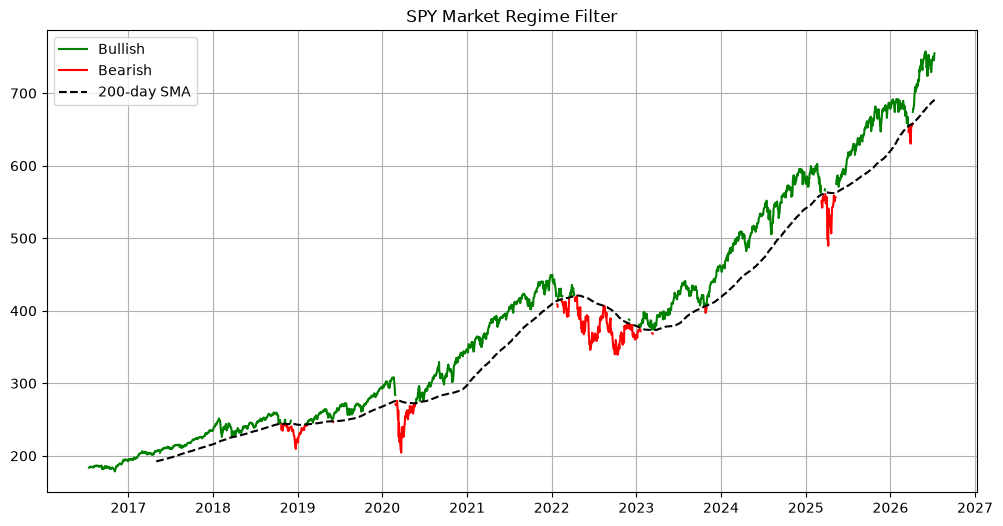

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot SPY price when filter is ON (green)
plt.plot(
    data.index,
    data.Close.SPY.where(~mrf_signal),
    color="green",
    label="Bullish"
)

# Plot SPY price when filter is OFF (red)
plt.plot(
    data.index,
    data.Close.SPY.where(mrf_signal),
    color="red",
    label="Bearish"
)

# Optional: plot the 200-day SMA
plt.plot(
    data.index,
    spy_sma_200,
    color="black",
    linestyle="--",
    label="200-day SMA"
)

plt.title("SPY Market Regime Filter")
plt.legend()
plt.grid(True)
plt.show()

### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
- #### Mechanism: A stock is only considered a candidate for investment if it is trading above its own 200-day SMA.

In [224]:
LOOK_BACK_TSMOM = 200
def sma_200(x: pd.Series) -> pd.Series:
    return x.rolling(LOOK_BACK_TSMOM).mean()

data_sma_200d = data.Close.apply(sma_200)
data_sma_200d.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,130.145897,270.697132,219.964669,130.208425,110.777188,93.69305,216.185685,288.00320,316.792216,66.798264,...,23.816181,112.299890,77.792554,134.422840,129.917147,67.36370,152.462221,91.279051,249.60275,116.244379
2026-07-07,130.173041,271.058853,220.159467,130.336425,110.596017,93.77055,215.706095,287.30055,317.467273,66.890601,...,23.813400,112.169463,77.843692,134.567449,129.822546,67.37295,152.568827,91.231702,249.33940,115.899998
2026-07-08,130.185371,271.439759,220.338952,130.423825,110.409577,93.83965,215.210328,286.56795,318.160658,66.994660,...,23.806226,112.020122,77.888994,134.715910,129.711906,67.36885,152.679021,91.173668,249.04660,115.548827
2026-07-09,130.226749,271.796822,220.501942,130.523075,110.212002,93.90615,214.731326,285.85170,318.913669,67.088160,...,23.801394,111.871109,77.931590,134.851449,129.599151,67.37080,152.772942,91.124578,248.81715,115.203583
2026-07-10,130.271577,272.096634,220.655197,130.638975,110.009223,93.97130,214.231754,285.14950,319.666774,67.197561,...,23.800533,111.744027,77.978212,134.998000,129.494779,67.37025,152.854819,91.077874,248.60270,114.866815


In [225]:
tsmom_filter = data.Close.gt(data_sma_200d)

<Axes: title={'center': 'Number of Stocks Above 200-Day SMA'}, xlabel='Date', ylabel='Number of Valid Stocks'>

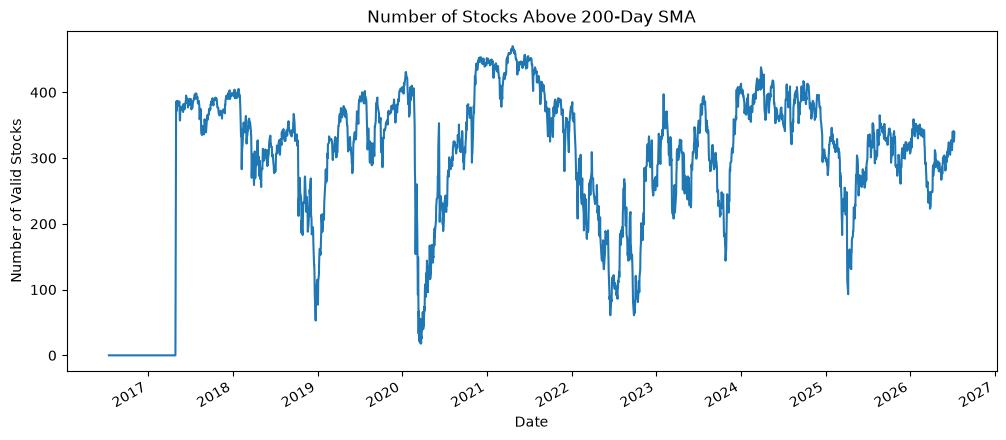

In [226]:
valid_stocks = tsmom_filter.sum(axis=1)

valid_stocks.plot(
    figsize=(12, 5),
    title="Number of Stocks Above 200-Day SMA",
    ylabel="Number of Valid Stocks",
    xlabel="Date"
)

### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
- #### Mechanism: Momentum is calculated over multiple lookback periods (60, 120, and 252 days) and then averaged to produce a robust momentum score.

In [227]:

cross_sect_mom_lookbacks = [60, 120, 252]
LOOKBACK_CSM = max(cross_sect_mom_lookbacks)

def cross_sect_mom(prices: pd.DataFrame, lookbacks: list[int] = cross_sect_mom_lookbacks) -> pd.DataFrame:
    # average raw return signal per asset, per lookback
    raw_signal = pd.concat(
        [(prices / prices.shift(l)) - 1 for l in lookbacks]
    ).groupby(level=0).mean()  # or however you're aligning — see note below
    return raw_signal

    # cross-sectional z-score: rank/normalize ACROSS assets at each date
    # z = raw_signal.sub(raw_signal.mean(axis=1), axis=0).div(raw_signal.std(axis=1), axis=0)
    # return z

csm_data = cross_sect_mom(data.Close)
csm_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,0.031087,0.298018,0.256556,0.091464,-0.191686,0.084724,-0.445377,-0.286522,0.344418,0.269252,...,-0.073194,-0.114758,0.106284,0.085609,-0.094515,0.176981,0.081246,-0.030119,0.035849,-0.429265
2026-07-07,0.039210,0.283375,0.258111,0.105513,-0.185334,0.098931,-0.417685,-0.258774,0.314203,0.284121,...,-0.073700,-0.109954,0.102650,0.126997,-0.088736,0.153807,0.087455,-0.029614,0.001586,-0.420232
2026-07-08,0.033592,0.301858,0.260043,0.057492,-0.181408,0.109187,-0.424452,-0.240181,0.342560,0.320953,...,-0.091966,-0.100352,0.087093,0.124229,-0.101595,0.157232,0.071220,-0.034959,0.011493,-0.422191
2026-07-09,0.057098,0.317166,0.241669,0.101866,-0.190160,0.096258,-0.434908,-0.252962,0.361250,0.290681,...,-0.111885,-0.095313,0.082625,0.072943,-0.100777,0.175587,0.051241,-0.030550,0.029508,-0.429021
2026-07-10,0.054902,0.314054,0.232274,0.105723,-0.193333,0.103752,-0.445033,-0.238949,0.369130,0.312261,...,-0.075644,-0.094605,0.101751,0.095403,-0.094923,0.159793,0.049083,-0.015629,0.033947,-0.426741


<Axes: title={'center': 'Cross-Sectional Momentums'}, xlabel='Date'>

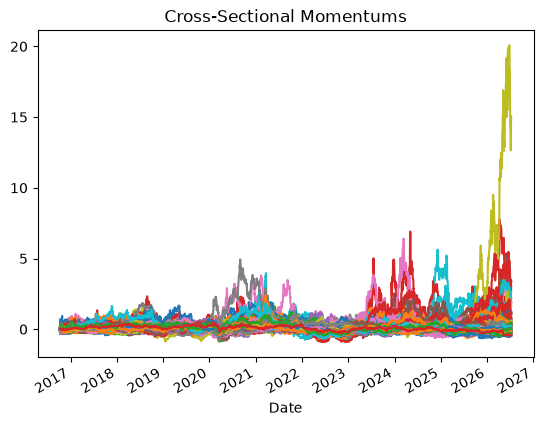

In [228]:
csm_data.plot(
    title='Cross-Sectional Momentums'
    , legend=False
)

### Part 4: Frog-in-the-Pan (FIP) Score: This factor measures the quality and consistency of a stock's trend.
- #### Mechanism: It calculates the ratio of positive daily returns over a 252-day period. A higher score indicates a smoother, more consistent uptrend, rather than one driven by a few large, volatile spikes.


In [229]:
LOOK_BACK_FIP = 252
daily_ret = (data.Close / data.Close.shift(1)) - 1
is_positive = daily_ret > 0
# Return was positive how many days
positive_days_sum = is_positive.rolling(LOOK_BACK_FIP).sum()
# Ratio of positive return days/total days
fip_data = positive_days_sum / 252
fip_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,0.515873,0.531746,0.503968,0.543651,0.468254,0.539683,0.464286,0.464286,0.547619,0.515873,...,0.464286,0.448413,0.539683,0.555556,0.507937,0.511905,0.511905,0.523810,0.488095,0.464286
2026-07-07,0.515873,0.527778,0.503968,0.543651,0.468254,0.539683,0.464286,0.464286,0.543651,0.519841,...,0.464286,0.448413,0.539683,0.555556,0.507937,0.507937,0.515873,0.519841,0.484127,0.464286
2026-07-08,0.515873,0.531746,0.503968,0.539683,0.468254,0.535714,0.464286,0.464286,0.547619,0.523810,...,0.464286,0.448413,0.539683,0.555556,0.507937,0.503968,0.511905,0.519841,0.484127,0.464286
2026-07-09,0.515873,0.531746,0.500000,0.543651,0.468254,0.531746,0.464286,0.464286,0.547619,0.519841,...,0.464286,0.448413,0.539683,0.551587,0.507937,0.507937,0.507937,0.519841,0.484127,0.460317
2026-07-10,0.515873,0.527778,0.496032,0.547619,0.468254,0.531746,0.464286,0.468254,0.551587,0.523810,...,0.468254,0.452381,0.539683,0.555556,0.507937,0.503968,0.507937,0.519841,0.484127,0.460317


<Axes: title={'center': 'Frog in the Pan Scores'}, xlabel='Date'>

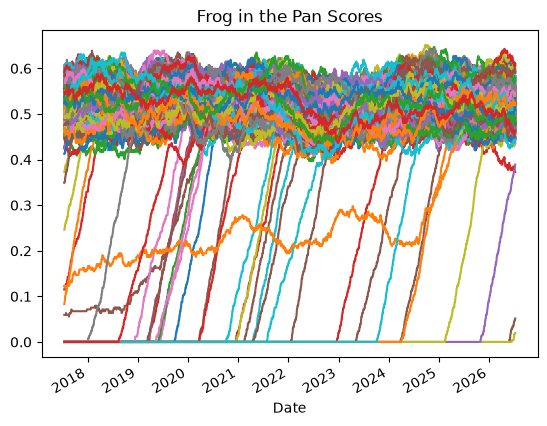

In [230]:
fip_data.plot(
    title='Frog in the Pan Scores'
    , legend=False
)

### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
- #### Mechanism: It calculates the rolling skewness of stock returns over a 90-day window. A high negative skew suggests a stock has a "tail" of large negative returns and is thus penalized in its final score.

In [231]:
LOOKBACK_SKEW = 90
log_returns = np.log(data.Close).diff()
skew_data = log_returns.rolling(LOOKBACK_SKEW).skew()
skew_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,2.756544,-0.441274,0.400088,0.031841,0.013093,-0.403624,-1.812084,-0.184058,-0.392970,0.158979,...,-0.042122,0.329403,0.260754,-0.562101,-0.179548,1.013884,-0.298893,-1.656931,0.382129,-4.508283
2026-07-07,2.753757,-0.413644,0.390517,-0.054081,0.011907,-0.416698,-1.824154,-0.188199,-0.352295,0.138924,...,-0.053372,0.300745,0.241603,-0.488691,-0.194083,1.042163,-0.326541,-1.650624,0.414468,-4.499430
2026-07-08,2.808020,-0.439205,0.388453,-0.091427,0.043887,-0.389609,-2.057976,-0.179443,-0.389524,0.113821,...,-0.081288,0.302401,0.258825,-0.487788,-0.185447,1.105147,-0.292604,-1.597114,0.401325,-4.480937
2026-07-09,2.708187,-0.450673,0.424049,-0.127701,0.061271,-0.370741,-2.045757,-0.174801,-0.402760,0.157876,...,-0.084061,0.266614,0.271368,-0.459116,-0.218579,-0.063863,-0.247724,-1.652496,0.401295,-4.488152
2026-07-10,2.739584,-0.440061,0.453933,-0.165436,0.045184,-0.338267,-2.020511,-0.187038,-0.420594,0.145740,...,0.021845,0.331257,0.258407,-0.458606,-0.240162,-0.047912,-0.226583,-1.630113,0.401652,-4.507969


<Axes: title={'center': 'Skew'}, xlabel='Date'>

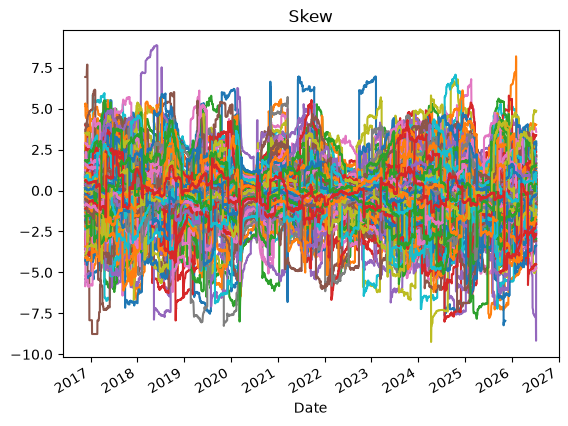

In [232]:
skew_data.plot(
    title='Skew'
    , legend=False
)

### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
- #### Mechanism: Once the top N stocks are selected, portfolio capital is allocated inversely proportional to each stock's historical volatility (standard deviation over 126 days). Less volatile stocks receive a larger capital allocation, and more volatile stocks receive a smaller one with the goal of equalizing the risk contribution of each position.

In [233]:
LOOKBACK_VOLATILITY = 126 
vol_data = data.Close.rolling(LOOKBACK_VOLATILITY).std()
vol_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,10.592613,19.610977,12.344651,6.651415,12.043840,3.125112,40.480734,32.006259,46.722103,6.094570,...,1.070500,6.390286,2.667503,10.824256,10.599012,7.157015,4.627864,4.799013,18.195935,20.685029
2026-07-07,10.547193,19.881539,12.748668,6.787504,11.899197,3.196897,40.481127,31.384551,46.137944,6.004926,...,1.071354,6.275906,2.639007,10.587101,10.530405,7.231718,4.697674,4.798977,18.343360,20.813132
2026-07-08,10.432726,20.175445,13.108744,6.834517,11.716319,3.252473,40.470104,30.765083,45.609253,5.939937,...,1.084461,6.192476,2.594064,10.394995,10.442920,7.289524,4.721371,4.794586,18.457545,20.921649
2026-07-09,10.263392,20.482349,13.399591,6.923591,11.506008,3.299654,40.234085,29.997751,45.310616,5.871293,...,1.095386,6.079261,2.551892,10.134478,10.321254,7.351357,4.718475,4.773709,18.645821,21.021474
2026-07-10,10.091866,20.750369,13.616179,7.042050,11.301366,3.338465,40.041680,29.125332,45.006887,5.776347,...,1.089072,6.022877,2.488676,9.794807,10.217446,7.403500,4.715406,4.770165,18.901544,21.135017


<Axes: title={'center': 'Volatility'}, xlabel='Date'>

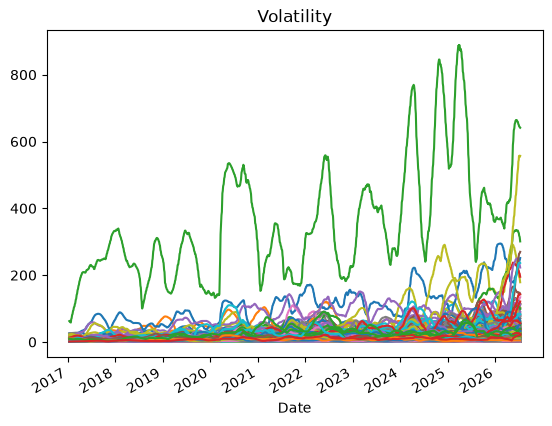

In [234]:
vol_data.plot(
    title='Volatility'
    , legend=False
)

In [235]:
UNIVERSE       : int = 0
MRF_SIGNAL    : int = 1
TSMOM_SIGNALS : int = 2
CSM_SIGNALS   : int = 3
FIP_SCORES    : int = 4
SKEWS         : int = 5
VOLS          : int = 6

strat_dat = (
    data.Close.columns
    , mrf_signal 
    , tsmom_filter
    , csm_data
    , fip_data
    , skew_data
    , vol_data
)

# find tickers with any all-NaN column across all signal frames
bad_tickers = set()
for df in strat_dat[1:]:
    if hasattr(df, 'columns'):
        bad_tickers.update(df.columns[df.isna().all()])

print("Dropping tickers with no data:", bad_tickers)

# rebuild strat_dat with those tickers removed from every frame
clean_universe = [t for t in strat_dat[UNIVERSE] if t not in bad_tickers]
strat_dat = (
    pd.Index(clean_universe),
    mrf_signal,
    tsmom_filter.drop(columns=bad_tickers, errors='ignore'),
    csm_data.drop(columns=bad_tickers, errors='ignore'),
    fip_data.drop(columns=bad_tickers, errors='ignore'),
    skew_data.drop(columns=bad_tickers, errors='ignore'),
    vol_data.drop(columns=bad_tickers, errors='ignore'),
)

common_start = min(df.dropna().index[0] for df in strat_dat[1:])
datas = [d[common_start:] if i > 0 else d for i, d in enumerate(strat_dat)]

Dropping tickers with no data: {'HONA', 'FDXF'}


In [ ]:
SELL_ALL_SIGNAL    : str = 'SELL_ALL_SIGNAL'
BASKET_EMPTY_SIGNAL: str = 'BASKET_EMPTY_SIGNAL'
NO_CSM_SIGNAL      : str = 'NO_CROSS_SECTIONAL_MOMENTUM_SIGNAL'

TOP_N      : int = 10
CSM_FACTOR : int  = 1
FIP_FACTOR : int  = 1
SKEW_FACTOR: int  = 1

TRADE_FREQ : str = 'ME'
assert TRADE_FREQ in ('ME', 'W', 'D', 'Y')

month_end_dates = strat_dat[-1].index.to_series().resample(TRADE_FREQ).first()
latest_date = month_end_dates.iloc[-1]

signal_df = pd.DataFrame(
      columns = [
          SELL_ALL_SIGNAL
          , BASKET_EMPTY_SIGNAL
          , *strat_dat[UNIVERSE]
        ]
    , index = month_end_dates.values
).fillna(0)

def normalize(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

def build_signal(d: pd.Timestamp):
    ### Part 1: Market Regime Filter
    if strat_dat[MRF_SIGNAL].loc[d]:
        signal_df.loc[d, SELL_ALL_SIGNAL] = 1
        return
    
    ### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
    basket = strat_dat[UNIVERSE][ 
        strat_dat[TSMOM_SIGNALS].loc[d]
    ]
    
    if basket.empty: 
        signal_df.loc[d, BASKET_EMPTY_SIGNAL] = 1
        return
    
    ### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
    csm = strat_dat[CSM_SIGNALS].loc[d][basket]
    csm = normalize(csm[csm>0])
    
    if csm.empty:
        signal_df.loc[d, NO_CSM_SIGNAL] = 1
        return

    winners = csm.index

    ### Part 4: Frog-in-the-Pan (FIP) Score: 
    fip  = normalize(strat_dat[FIP_SCORES].loc[d, winners])

    ### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
    skew = normalize(strat_dat[SKEWS].loc[d, winners])

    score = (
          (CSM_FACTOR  * csm)
        + (FIP_FACTOR  * fip)
        + (SKEW_FACTOR * skew)
    )
    top_picks = score.sort_values(ascending=False).head(TOP_N)
    
    ### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
    vol = strat_dat[VOLS].loc[d, top_picks.index]
    inv_vol = 1 / vol
    weights = inv_vol / inv_vol.sum()

    signal_df.loc[d, weights.index] = weights.values

build_signal(latest_date)

signal_df.loc[latest_date].sort_values().tail(TOP_N)

SNDK    0.006872
MU      0.014539
LITE    0.018294
WDC     0.026774
URI     0.033292
DELL    0.035909
KEYS    0.070841
FLEX    0.103097
DVA     0.114626
MNST    0.575757
Name: 2026-07-01 00:00:00, dtype: object

In [237]:
for d in signal_df.index: build_signal(d)

In [239]:
recent = signal_df.tail(24)
recent.loc[:, (recent != 0).any(axis=0)]

,SELL_ALL_SIGNAL,AFL,ANET,APP,AXON,CAH,CASY,CHRW,CIEN,COHR,...,SNDK,STX,TPL,TRMB,TTWO,URI,VST,WBD,WDC,WSM
2024-08-01,0,0,0,0,0,0,0.03519,0,0,0,...,0,0,0.031916,0,0,0,0.070137,0,0,0
2024-09-03,0,0.150529,0,0,0,0,0,0,0,0,...,0,0,0.029506,0,0,0,0,0,0,0
2024-10-01,0,0,0,0.088129,0,0,0,0,0,0,...,0,0,0.034359,0,0,0,0.112451,0,0,0
2024-11-01,0,0,0,0.041891,0,0,0,0,0,0,...,0,0,0,0,0,0,0.065022,0,0,0
2024-12-02,0,0,0,0.017865,0.013368,0,0,0,0,0,...,0,0,0,0,0,0,0.050832,0,0,0
2025-01-02,0,0,0,0.012818,0.010795,0,0,0,0,0,...,0,0,0,0.179008,0,0,0.044989,0,0,0.06959
2025-02-03,0,0,0,0.013302,0.012612,0,0,0,0,0,...,0,0,0,0.184364,0,0,0,0,0,0.05441
2025-03-03,0,0,0,0.016058,0,0,0,0,0,0,...,0,0,0.025073,0,0.095018,0,0,0,0,0.061588
2025-04-01,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-05-01,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
